# 使用PCA对人脸图片进行处理

此部分作业要求使用PCA技术对给定的人脸数据集进行处理，你需要在该文件中完成你的代码，并输出结果。



本次使用到的人脸数据集是 ORL人脸数据集，共包含40个不同人的400张图像。此数据集下包含40个目录，每个目录下有10张图像，每个目录表示一个不同的人。所有的图像是以PGM格式存储，灰度图，图像大小宽度为92，高度为112。



数据集中部分图像示例：

![image-20230428112024592](./faces.png)



在本次作业中，你需要**按顺序**完成以下内容并且在该文件中**保留要求**的输出结果：

1. 将数据集划分为80%的训练集，20%的测试集，在训练集上使用PCA将特征维度降为100，即得到100个特征和其对应的特征向量，并使用训练得到的PCA将测试集维度也压缩到100，**输出：压缩后的训练集维度和测试集维度、经过PCA得到的特征向量维度**。

2. 得到100个特征向量后，**使用这些向量重建特征脸并输出**。示例：

   ![image2](./feature.png)

3. 使用这100个特征和对应的特征向量，自行在训练集和测试集中**分别**选择**5张**人脸图片进行人脸重建并**输出对比图**。示例：

   ![image2](./restore.png)

4. **输出**降维后**每个**新特征向量所占的信息量占原始数据总信息量的百分比，以及所有返回特征所携带的**信息量总和**是原始数据的多少；

5. **画出**特征个数和所携带信息数的曲线图，此处特征数**上限设置为150**，此处以150为示例：

   ![image2](./information.png)

6.  保留特征数为150，得到的训练集每次保留前（n=n+1，n初值为1）个特征，分别训练一个KNN分类器，KNN分类器的参数*n_neighbors*为3，观察并验证测试集在使用其前n个特征时KNN分类的准确率。**注意：此处仅进行一次PCA**,输出：不同的特征保留数和准确率的曲线图。此处以*n_neighbors=5*为示例：

   ![image2](./acc.png)

   **本次作业严禁抄袭，一经发现严肃处理**


#  附加题

若感兴趣，可以自行拍摄自己或舍友的人脸照片、或者其他较为简单且特征明显的数据集进行PCA操作。


In [1]:
# 本次作业你可能需要用到的包和函数

%matplotlib inline
# 导入所需模块
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# plt显示灰度图片
def plt_show(img):
    plt.imshow(img,cmap='gray')
    plt.show()

# 读取一个文件夹下的所有图片，输入参数是文件名，返回文件地址列表
def read_directory(directory_name):
    faces_addr = []
    for filename in os.listdir(directory_name):
        faces_addr.append(directory_name + "/" + filename)
    return faces_addr

In [ ]:
# Your Code

In [60]:
def load_faces(dir_list):
    images = []
    labels = []
    
    for person_dir in dir_list:
        person_id = int(person_dir.split('//s')[1])
        face_files = read_directory(person_dir)
        
        for face_file in face_files:
            img = cv2.imread(face_file, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img_flat = img.flatten()
                images.append(img_flat)
                labels.append(person_id)
    
    return [np.array(images), np.array(labels)]


image_datasets = load_faces(read_directory("data/"))
X_train, X_test, y_train, y_test = train_test_split(image_datasets[0], image_datasets[1], test_size=0.2, random_state=42)

In [61]:
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

eigenfaces = pca.components_

print(f"Compressed training data shape: {X_train_pca.shape}")
print(f"Compressed testing data shape: {X_test_pca.shape}")
print(f"PCA feature vectors shape: {eigenfaces.shape}")

Compressed training data shape: (320, 100)
Compressed testing data shape: (80, 100)
PCA feature vectors shape: (100, 10304)


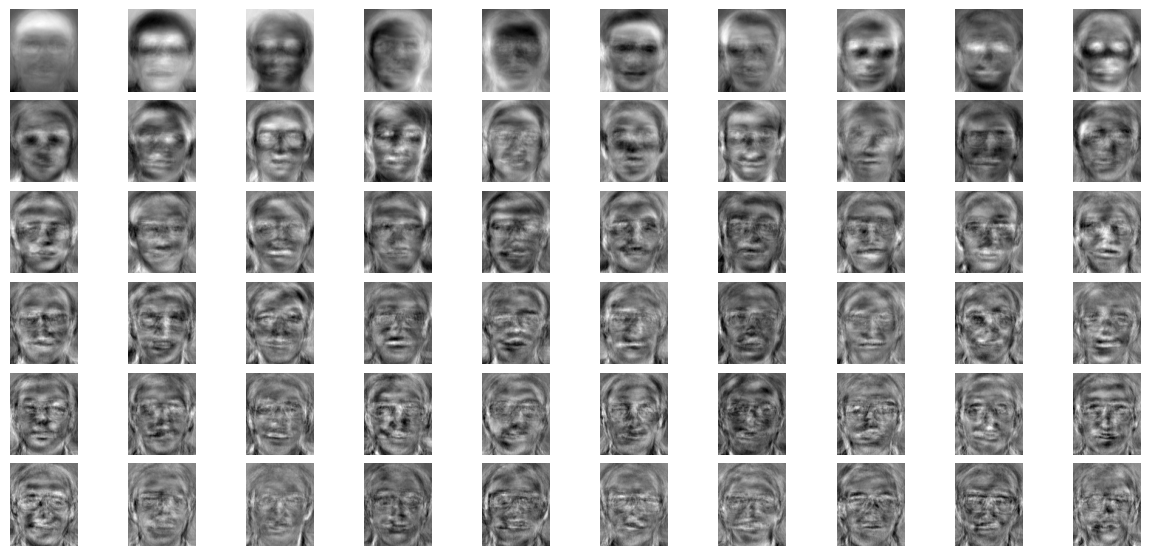

In [62]:
plt.figure(figsize=(12, 6))
n = 60
for i in range(n):
    plt.subplot(6, 10, i+1)
    eigenface = eigenfaces[i].reshape(112, 92)
    eigenface = (eigenface - eigenface.min()) / (eigenface.max() - eigenface.min())
    plt.imshow(eigenface, cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1, top=0.92)
plt.show()



In [63]:
def reconstruct_face(pca_face, pca_components, mean_face):
    return np.dot(pca_face, pca_components) + mean_face


def reconstruct_face_display(indices, eigenfaces, mean_face):
    plt.figure(figsize=(4, 6))
    for i, idx in enumerate(indices):
        plt.subplot(5, 2, 2*i+1)
        original_face = X_train[idx].reshape(112, 92)
        plt.imshow(original_face, cmap='gray')
        plt.axis('off')

        plt.subplot(5, 2, 2*i+2)
        reconstructed_face = reconstruct_face(X_train_pca[idx], eigenfaces, mean_face).reshape(112, 92)
        plt.imshow(reconstructed_face, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.01, hspace=0.1)
    plt.show()

In [ ]:
train_indices = np.random.choice(len(X_train), 5, replace=False)
test_indices = np.random.choice(len(X_test), 5, replace=False)


mean_face = pca.mean_

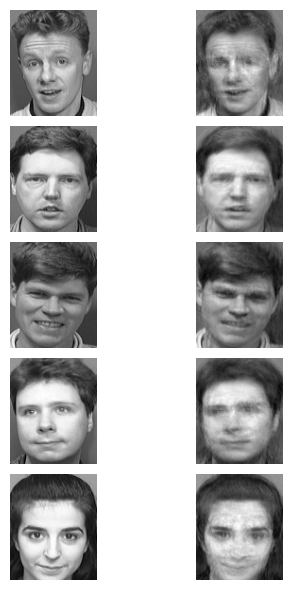

In [65]:
reconstruct_face_display(train_indices, eigenfaces, mean_face)

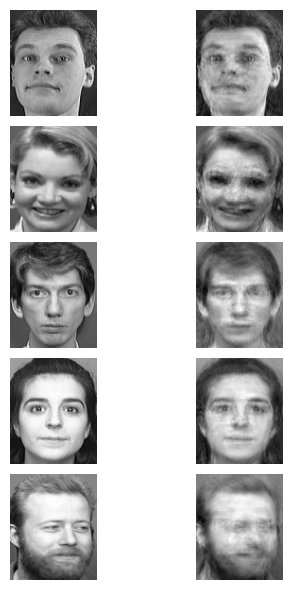

In [66]:
reconstruct_face_display(test_indices, eigenfaces, mean_face)

In [67]:
explained_variance_ratio = pca.explained_variance_ratio_

total_variance = np.sum(explained_variance_ratio) * 100

print("The first 100 eigenfaces explain the following percentage of variance:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"feature {i+1}: {ratio*100:.4f}%")

print(f"\nTotal variance explained by the first 100 eigenfaces: {total_variance:.4f}%")

The first 100 eigenfaces explain the following percentage of variance:
feature 1: 17.3641%
feature 2: 12.9107%
feature 3: 6.8209%
feature 4: 5.8736%
feature 5: 5.1205%
feature 6: 3.3536%
feature 7: 2.4295%
feature 8: 2.3206%
feature 9: 1.9438%
feature 10: 1.8900%
feature 11: 1.5333%
feature 12: 1.3997%
feature 13: 1.1740%
feature 14: 1.1588%
feature 15: 0.9834%
feature 16: 0.9691%
feature 17: 0.9009%
feature 18: 0.8561%
feature 19: 0.7217%
feature 20: 0.6941%
feature 21: 0.6772%
feature 22: 0.6627%
feature 23: 0.6161%
feature 24: 0.5731%
feature 25: 0.5335%
feature 26: 0.5271%
feature 27: 0.4991%
feature 28: 0.4964%
feature 29: 0.4695%
feature 30: 0.4552%
feature 31: 0.4404%
feature 32: 0.4133%
feature 33: 0.4055%
feature 34: 0.3851%
feature 35: 0.3667%
feature 36: 0.3601%
feature 37: 0.3553%
feature 38: 0.3355%
feature 39: 0.3230%
feature 40: 0.3123%
feature 41: 0.3018%
feature 42: 0.2968%
feature 43: 0.2910%
feature 44: 0.2870%
feature 45: 0.2763%
feature 46: 0.2664%
feature 47: 0.26

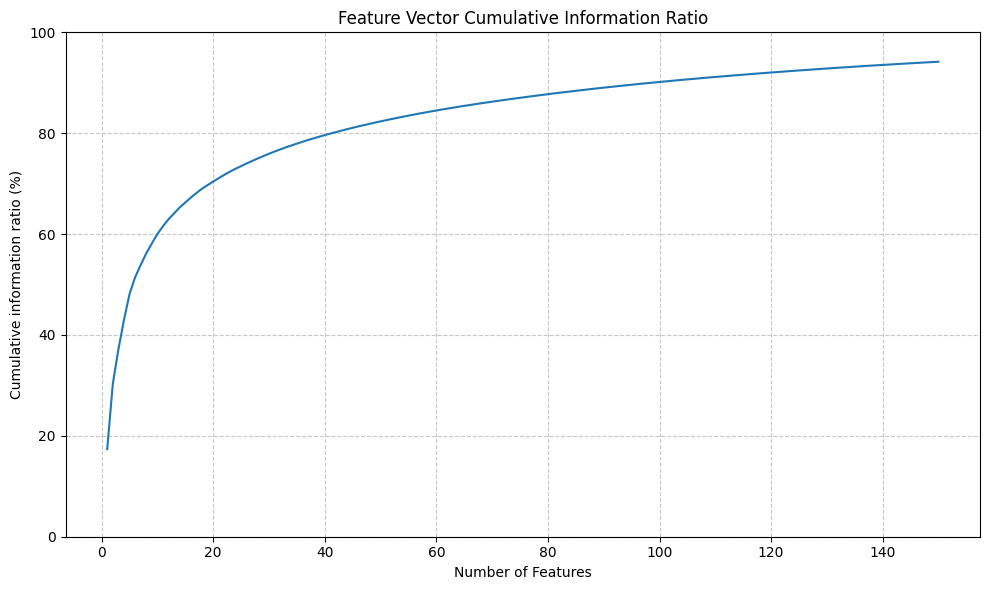

In [71]:

pca_full = PCA(n_components=150)
pca_full.fit(X_train)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 6))
plt.plot(range(1, 151), cumulative_variance)
plt.xlabel('Number of Features')
plt.ylabel('Cumulative information ratio (%)')
plt.ylim(0, 100)
plt.title('Feature Vector Cumulative Information Ratio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

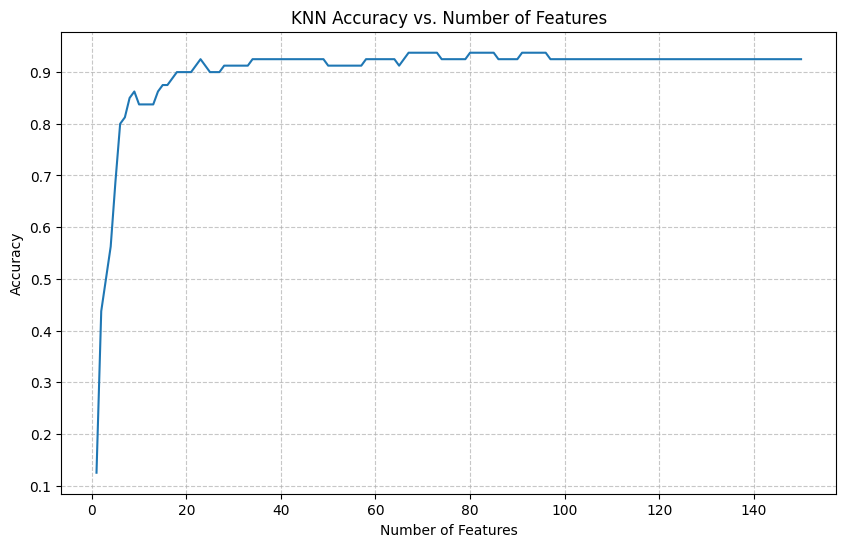

In [72]:
pca = PCA(n_components=150)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

accuracies = []
feature_nums = range(1, 151)

for n_features in feature_nums:
    X_train_truncated = X_train_pca[:, :n_features]
    X_test_truncated = X_test_pca[:, :n_features]
    
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_truncated, y_train)
    
    accuracy = knn.score(X_test_truncated, y_test)
    accuracies.append(accuracy)

plt.figure(figsize=(10, 6))
plt.plot(feature_nums, accuracies)
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs. Number of Features')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()